In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [69]:
df = pd.read_csv('../data/final.csv')

In [70]:
df.head()

,_id_x,datetime,wdLoad,_id_y,temp,rh
0,65ec7877a00f951ad65cfcb2,2017-12-31 18:30:00+00:00,227.02,65ec7952a00f951ad6604b13,19.12,68.06
1,65ec7877a00f951ad65cfcb3,2017-12-31 18:45:00+00:00,226.78,65ec7952a00f951ad6604b14,19.06,68.14
2,65ec7877a00f951ad65cfcb4,2017-12-31 19:00:00+00:00,225.58,65ec7952a00f951ad6604b15,18.96,68.32
3,65ec7877a00f951ad65cfcb5,2017-12-31 19:15:00+00:00,224.05,65ec7952a00f951ad6604b16,18.97,66.54
4,65ec7877a00f951ad65cfcb6,2017-12-31 19:30:00+00:00,222.34,65ec7952a00f951ad6604b17,18.90,67.32


without lag

In [71]:
df1 = df.copy()

df1['datetime'] = pd.to_datetime(df1['datetime'])
df1 = df1.sort_values('datetime')

df1['hour'] = df1['datetime'].dt.hour
df1['dayofweek'] = df1['datetime'].dt.dayofweek

df1 = df1.dropna()

In [72]:
X1 = df1[['temp','rh','hour','dayofweek']]
y1 = df1['wdLoad']

In [73]:
model1 = LinearRegression()
model1.fit(X1, y1)

preds1 = model1.predict(X1)

rmse1 = np.sqrt(mean_squared_error(y1, preds1))
print("RMSE (No Lag):", rmse1)

RMSE (No Lag): 81.96002327366045


In [74]:
coef_df = pd.DataFrame({
    'Feature': X1.columns,
    'Coefficient': model1.coef_
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

     Feature  Coefficient
0       temp    13.200556
1         rh    -0.175199
2       hour    -2.960482
3  dayofweek    -8.771784


In [75]:
import shap

explainer = shap.LinearExplainer(model1, X1)
shap_values = explainer(X1)

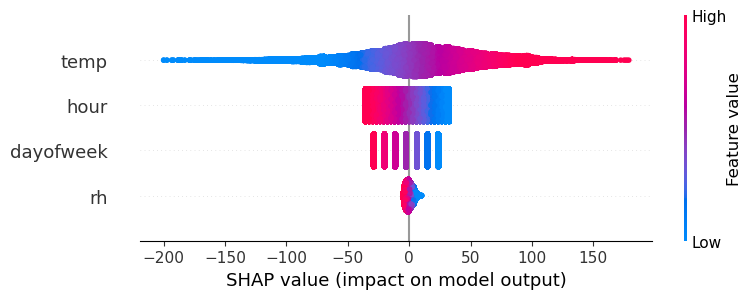

In [76]:
shap.summary_plot(shap_values, X1)

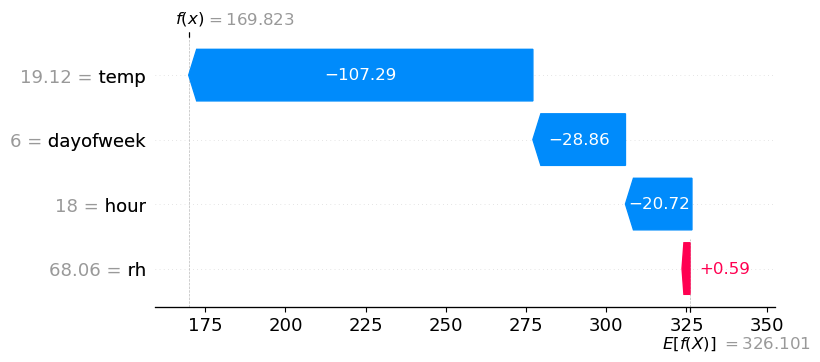

In [77]:
shap.plots.waterfall(shap_values[0])

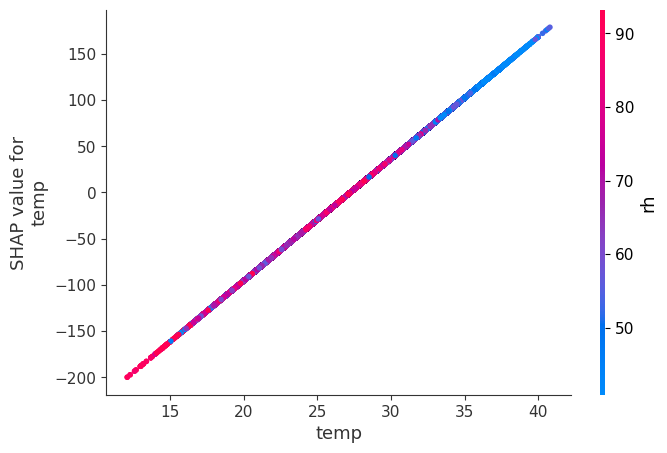

In [78]:
shap.dependence_plot("temp", shap_values.values, X1)

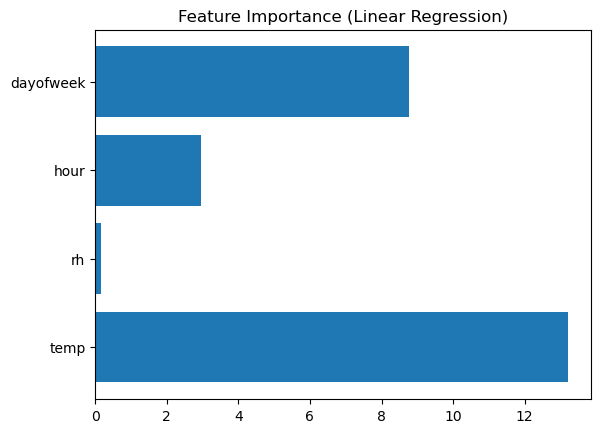

In [79]:
importance = np.abs(model1.coef_)

plt.barh(X1.columns, importance)
plt.title("Feature Importance (Linear Regression)")
plt.show()

In [80]:
from lime.lime_tabular import LimeTabularExplainer

explainer1 = LimeTabularExplainer(
    X1.values,
    feature_names=X1.columns,
    mode='regression',
    discretize_continuous=False
)

exp1 = explainer1.explain_instance(
    X1.iloc[0].values,
    model1.predict
)

print(exp1.as_list())

[('temp', 45.642371658624256), ('hour', -20.4416913999622), ('dayofweek', -17.49147419759999), ('rh', -2.8066787538601856)]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


With lag


In [81]:
df2 = df.copy()

df2['datetime'] = pd.to_datetime(df2['datetime'])
df2 = df2.sort_values('datetime')
df2.set_index('datetime', inplace=True)

# Time features
df2['hour'] = df2.index.hour
df2['dayofweek'] = df2.index.dayofweek

# ✅ Lag features
df2['lag_1'] = df2['wdLoad'].shift(1)
df2['lag_24'] = df2['wdLoad'].shift(24)
df2['lag_168'] = df2['wdLoad'].shift(168)

# Drop NaN
df2 = df2.dropna()

In [82]:
X2 = df2[['temp','rh','hour','dayofweek','lag_1','lag_24','lag_168']]
y2 = df2['wdLoad']

In [83]:
model2 = LinearRegression()
model2.fit(X2, y2)

preds2 = model2.predict(X2)

In [84]:

rmse2 = np.sqrt(mean_squared_error(y2, preds2))
print("RMSE :", rmse2)

RMSE : 4.012232680590503


In [85]:
coef_df = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

     Feature  Coefficient
4      lag_1     0.998515
6    lag_168     0.020477
1         rh     0.019499
5     lag_24    -0.021088
0       temp    -0.139849
2       hour    -0.288997
3  dayofweek    -0.330702


In [86]:
import shap

explainer = shap.LinearExplainer(model2, X2)
shap_values = explainer(X2)

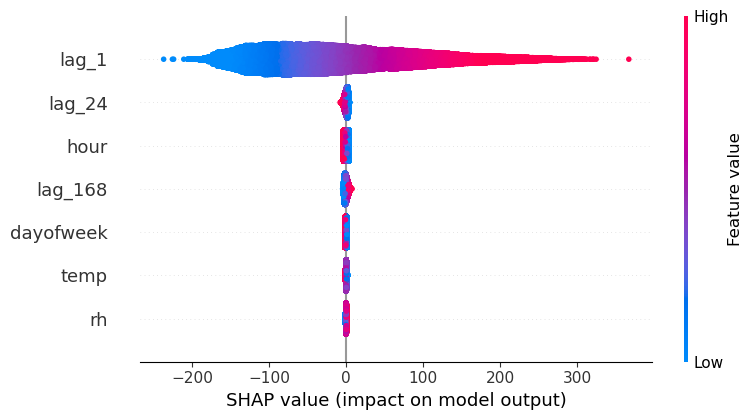

In [87]:
shap.summary_plot(shap_values, X2)

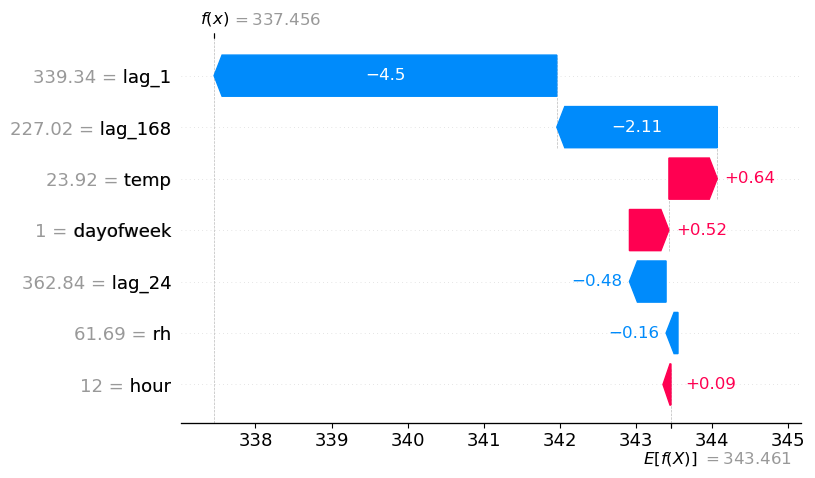

In [88]:
shap.plots.waterfall(shap_values[0])

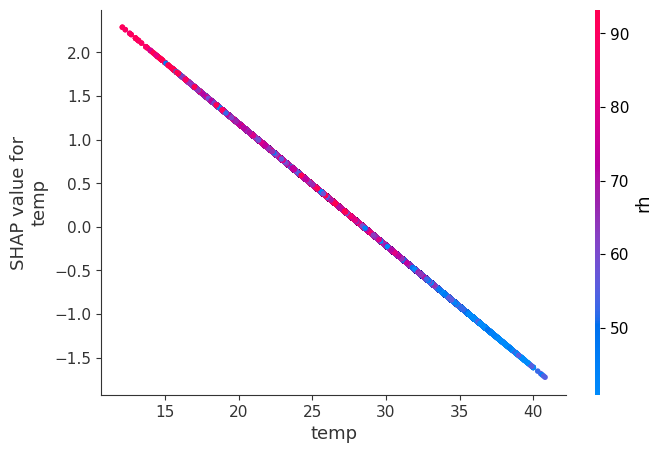

In [89]:
shap.dependence_plot("temp", shap_values.values, X2)

In [90]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X2.values,
    feature_names=X2.columns,
    mode='regression',
    discretize_continuous=False
)

exp = explainer.explain_instance(
    X2.iloc[0].values,
    model2.predict
)

print(exp.as_list())

[('lag_1', 99.94991122711929), ('lag_24', -2.109169913816912), ('lag_168', 2.049409419693237), ('hour', -2.000703557704342), ('dayofweek', -0.6610211423340916), ('temp', -0.4816141757864403), ('rh', 0.3123775820002668)]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


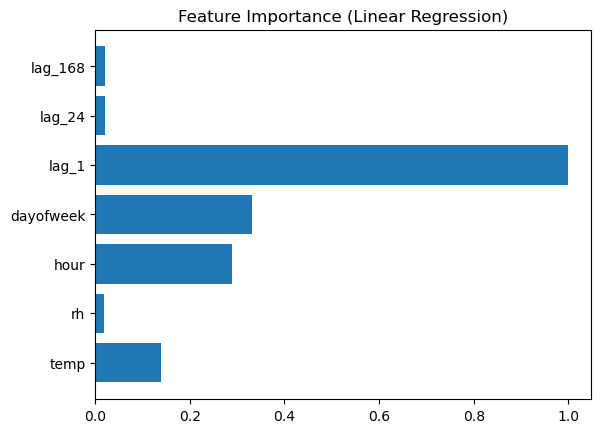

In [91]:
importance = np.abs(model2.coef_)

plt.barh(X2.columns, importance)
plt.title("Feature Importance (Linear Regression)")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


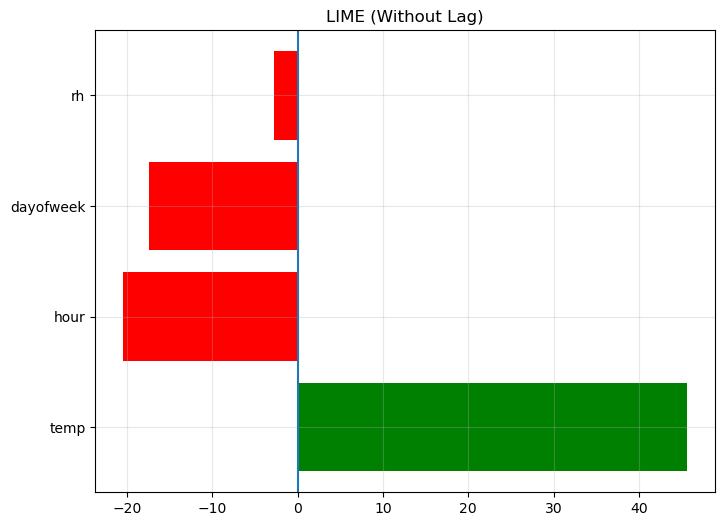

In [92]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

explainer1 = LimeTabularExplainer(
    X1.values,
    feature_names=X1.columns,
    mode='regression',
    discretize_continuous=False
)

exp1 = explainer1.explain_instance(
    X1.iloc[0].values,
    model1.predict
)

# Convert to plot
lime_list1 = exp1.as_list()

features1 = [i[0] for i in lime_list1]
values1 = [i[1] for i in lime_list1]

colors1 = ['green' if v > 0 else 'red' for v in values1]

plt.figure(figsize=(8,6))
plt.barh(features1, values1, color=colors1)
plt.title("LIME (Without Lag)")
plt.axvline(0)
plt.grid(alpha=0.3)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


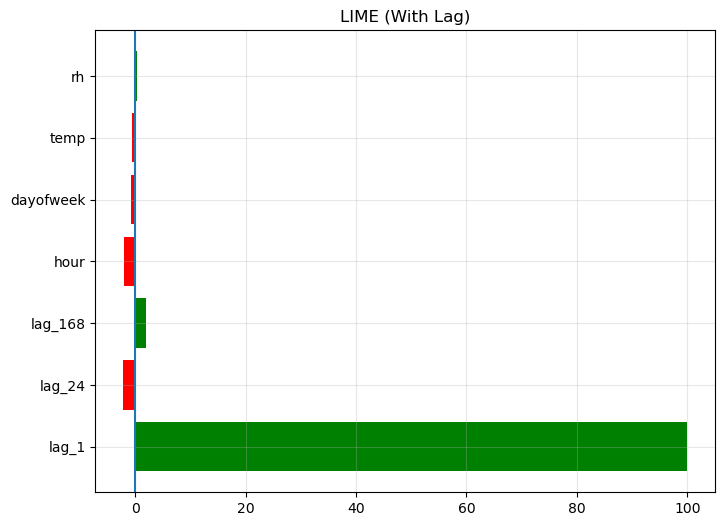

In [93]:
explainer2 = LimeTabularExplainer(
    X2.values,
    feature_names=X2.columns,
    mode='regression',
    discretize_continuous=False
)

exp2 = explainer2.explain_instance(
    X2.iloc[0].values,
    model2.predict
)

lime_list2 = exp2.as_list()

features2 = [i[0] for i in lime_list2]
values2 = [i[1] for i in lime_list2]

colors2 = ['green' if v > 0 else 'red' for v in values2]

plt.figure(figsize=(8,6))
plt.barh(features2, values2, color=colors2)
plt.title("LIME (With Lag)")
plt.axvline(0)
plt.grid(alpha=0.3)
plt.show()